# <center>Confirmation Bias in LLMS</center>

# Libraries & Setup
- Imports the required Python libraries.
- Connects to the Azure GPT-4o endpoint using the provided API key.

In [35]:
import re
import time
import numpy as np
import pandas as pd
from openai import OpenAI

In [ ]:
# Connect to the Azure GPT-4o deployment
endpoint = "https://course-gpt4o-resource.openai.azure.com/openai/v1"
deployment_name = "gpt-4o"
api_key = "xxxxxxxx-your-api-key-xxxxxxxx"

client = OpenAI(
    base_url=endpoint,
    api_key=api_key)

In [37]:
df = pd.read_csv("items.csv")

In [38]:
df

,item_id,A_statement,notA_statement,antonym_statement,ground_truth_A,ground_truth_notA,ground_truth_antonym,antonym_type,statement_type
0,1,The Earth orbits the Sun.,The Earth does not orbit the Sun.,The Sun orbits the Earth.,True,False,False,contradictory,universal_truth
1,2,Water boils at 100°C at sea level.,Water does not boil at 100°C at sea level.,Water boils at 0°C at sea level.,True,False,False,contrary,universal_truth
2,3,Photosynthesis produces oxygen.,Photosynthesis does not produce oxygen.,Photosynthesis consumes oxygen.,True,False,False,contradictory,universal_truth
3,4,The human heart has four chambers.,The human heart does not have four chambers.,The human heart has two chambers.,True,False,False,contrary,universal_truth
4,5,Mammals are warm-blooded animals.,Mammals are not warm-blooded animals.,Mammals are cold-blooded animals.,True,False,False,contrary,universal_truth
...,...,...,...,...,...,...,...,...,...
145,146,Bacteria survive extreme cold.,Bacteria do not survive extreme cold.,Bacteria die in extreme cold.,NaN,NaN,NaN,NaN,not_universal_truth
146,147,Animals hibernate.,Animals do not hibernate.,Animals stay active in winter.,NaN,NaN,NaN,NaN,not_universal_truth
147,148,Minerals dissolve in water.,Minerals do not dissolve in water.,Minerals remain insoluble in water.,NaN,NaN,NaN,NaN,not_universal_truth
148,149,Plants grow faster in sunlight.,Plants do not grow faster in sunlight.,Plants grow slower in sunlight.,NaN,NaN,NaN,NaN,not_universal_truth


# Prompt Templates
- **Neutral** → Basic truth judgment.
- **Logical** → Enforces classical logic rules (if A is true, ¬A must be false).
- **Direct Contrast** → Model sees A and NOT-A together.

In [39]:
NEUTRAL_PROMPT = """
You are evaluating short statements one at a time.
Respond with exactly one of: True, False, or Insufficient info.
Rely on standard definitions and widely accepted facts only.
If the statement is unclear, controversial, or depends on uncertain assumptions, prefer "Insufficient info".
After your label, include "Confidence: <0-100>" on a new line, where 0 means totally unsure and 100 means completely certain.
Do not provide explanations.

Statement: {STATEMENT}
"""

# added explicit instruction to use "Insufficient info" for unclear/controversial cases

LOGICAL_PROMPT = """
You are evaluating short statements one at a time.
Respond with exactly one of: True, False, or Insufficient info.
Rely on standard definitions and widely accepted facts only.
Also apply classical logic: if A is True, then not-A must be False, and vice versa.
If you are not sure which option is logically or factually correct, use "Insufficient info" with low confidence.
After your label, include "Confidence: <0-100>" on a new line.
Do not provide explanations.

Statement: {STATEMENT}
"""

# stresses logical constraints and encourages low confidence or "Insufficient info" when unsure

DIRECT_CONTRAST_PROMPT = """
You are presented with two opposing statements.
Evaluate each independently using the same criteria.
For each statement, respond with exactly one of: True, False, or Insufficient info.
If you judge one statement as True and the other as False, make sure your confidence reflects this asymmetry.
If both seem unclear or depend on missing information, prefer "Insufficient info" with moderate or low confidence.
After each label, include "Confidence: <0-100>".
Do not provide explanations.

Statement A: {STATEMENT_A}
Statement B: {STATEMENT_B}
"""

# encourages asymmetric confidence when one side is clearly better, and "Insufficient info" when both are unclear

In [40]:
# Creates the actual prompt sent to the model
def build_prompt(statement, mode="neutral", statement_B=None):
    if mode == "neutral":
        return NEUTRAL_PROMPT.format(STATEMENT=statement)

    elif mode == "logical":
        return LOGICAL_PROMPT.format(STATEMENT=statement)

    elif mode == "contrast":
        return DIRECT_CONTRAST_PROMPT.format(
            STATEMENT_A=statement,
            STATEMENT_B=statement_B)

    else:
        raise ValueError("Unknown mode")

# Query Model Function
Sends a prompt to the Azure-hosted GPT-4o model and returns its text output.

Steps:
- Sends a prompt to Azure GPT-4o → Calls the deployed model with deterministic settings (`temperature=0`).
- Returns the model’s text output → Extracts `.choices[0].message.content` from the API response.
- Handles Azure content filtering → If a safety filter is triggered, it retries and eventually returns `"FILTERED: True Confidence: 0"`.
- Handles rate limiting (429) → Uses exponential backoff (`delay *= 2`) and retries automatically.
- Catches unexpected errors → Prints the error (unless `quiet=True`) and retries.
- Retries multiple times → Up to `max_retries` attempts before giving up.
- Returns a fallback error message → `"ERROR: Could not get response"` if all retries fail.

In [41]:
def query_model(prompt, max_retries=3, delay=1, quiet=False):
    for attempt in range(max_retries):
        try:
            # Send request to Azure GPT-4o
            response = client.chat.completions.create(
                model=deployment_name,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,      # Deterministic output
                max_tokens=50)        # Limit output length for consistency

            # Successful output
            return response.choices[0].message.content

        # Azure content filter
        except Exception as e:
            if "content_filter" in str(e) or "filtered" in str(e):
                if not quiet:
                    print(f"⚠️ Filtered. Attempt {attempt + 1}/{max_retries}")

                # Last retry → return special marker
                if attempt == max_retries - 1:
                    return "FILTERED: True Confidence: 0"

            # Rate limit (429) → exponential backoff
            elif "rate limit" in str(e).lower() or "429" in str(e):
                if not quiet:
                    print(f"⏳ Rate limited. Waiting {delay * 2} seconds...")
                time.sleep(delay * 2)
                delay *= 2       # Exponential backoff
                continue

            # Unexpected error
            else:
                if not quiet:
                    print(f"❌ Error: {e}")

            # Wait before next retry
            time.sleep(delay)

    # If all attempts fail
    return "ERROR: Could not get response"

# Parser
Extracts two things from the model’s raw text output:
- Label → `"True"`, `"False"`, or `"Insufficient info"`
- Confidence → An integer score (0–100)

This parser also handles special cases:
- Filtered prompts → Azure blocks the content.
- Model errors → Network issues, timeout, etc.
- Unexpected output → Model returns something not matching the expected format.

In [42]:
def parse_response(text):
    text = text.strip()

    # Azure filtered the prompt
    if "FILTERED:" in text:
        # Split at 'FILTERED:' to inspect what comes after
        parts = text.split("FILTERED:")
        filtered_text = parts[1].strip() if len(parts) > 1 else ""

        # Try to extract label (True / False / Insufficient info)
        label_match = re.search(r"\b(True|False|Insufficient info)\b",
                                filtered_text,
                                re.IGNORECASE)
        if label_match:
            label = label_match.group(1).capitalize()
        else:
            # If the model didn't produce a real label → mark as filtered
            label = "Filtered"

        # Extract confidence (usually 0)
        conf_match = re.search(r"Confidence:\s*(\d+)", text)
        conf = int(conf_match.group(1)) if conf_match else 0

        return label, conf

    # Model error detected
    if "ERROR:" in text:
        return "Error", 0

    # Normal response parsing → extract label via regex
    label_match = re.search(r"\b(True|False|Insufficient info)\b",
                            text,
                            re.IGNORECASE)
    if label_match:
        label = label_match.group(1).capitalize()
    else:
        # Fallback → check manually if any expected label appears
        for expected in ["True", "False", "Insufficient info"]:
            if expected.lower() in text.lower():
                label = expected
                break
        else:
            # No valid label detected at all
            label = "ParsingError"

    # Extract confidence score
    conf_match = re.search(r"Confidence:\s*(\d+)", text)
    if conf_match:
        conf = int(conf_match.group(1))
    else:
        # Fallback pattern (handles variations like "confidence is 72")
        alt_match = re.search(r"confidence.*?(\d+)",
                              text,
                              re.IGNORECASE)
        conf = int(alt_match.group(1)) if alt_match else 0

    return label, conf

# Run the Experiment
- Builds prompts (A, not-A, antonym) depending on the experimental mode.
- Queries the model for each prompt.
- Parses responses using `parse_response()` → Extracts the model’s label and confidence score.
- Stores results in a list of dicts → Later converted to a DataFrame.
- Periodically saves partial results (after every N items) → Prevents losing progress when Azure blocks requests or the runtime crashes.

In [43]:
def run_experiment(df, mode, quiet=False, save_every=10):
    results = []
    total_items = len(df)

    for idx, row in df.iterrows():

        # Progress indicator every 5 items
        if not quiet and (idx + 1) % 5 == 0:
            print(f"Processing item {idx + 1}/{total_items}...")

        # Extract statements from dataset row
        A = row["A_statement"]
        notA = row["notA_statement"]
        antonym = row["antonym_statement"]

        # Mode 1: NEUTRAL + LOGICAL → these modes evaluate each statement separately.
        if mode in ["neutral", "logical"]:
            # Build prompts (single-statement format)
            prompt_A = build_prompt(A, mode=mode)
            prompt_notA = build_prompt(notA, mode=mode)
            prompt_ant = build_prompt(antonym, mode=mode)

            # Query Azure GPT
            raw_A = query_model(prompt_A, quiet=quiet)
            raw_notA = query_model(prompt_notA, quiet=quiet)
            raw_ant = query_model(prompt_ant, quiet=quiet)

            # Parse responses (label + confidence)
            label_A, conf_A = parse_response(raw_A)
            label_notA, conf_notA = parse_response(raw_notA)
            label_ant, conf_ant = parse_response(raw_ant)

        # Mode 2: CONTRAST → model evaluates A vs not-A together in one prompt, and A vs antonym in another prompt.
        elif mode == "contrast":

            # A vs not-A
            prompt_pair = build_prompt(A, mode="contrast", statement_B=notA)
            raw_pair = query_model(prompt_pair, quiet=quiet)

            # Extract two labels + two confidence scores
            labels = re.findall(r"(True|False|Insufficient info)", raw_pair, re.IGNORECASE)
            confs = re.findall(r"Confidence:\s*(\d+)", raw_pair)

            if len(labels) >= 2:
                label_A, label_notA = labels[0].capitalize(), labels[1].capitalize()
            else:
                label_A, label_notA = "ParsingError", "ParsingError"

            if len(confs) >= 2:
                conf_A, conf_notA = int(confs[0]), int(confs[1])
            else:
                conf_A, conf_notA = 0, 0

            # A vs antonym
            prompt_pair2 = build_prompt(A, mode="contrast", statement_B=antonym)
            raw_pair2 = query_model(prompt_pair2, quiet=quiet)

            # Extract two labels + two confidence scores
            labels2 = re.findall(r"(True|False|Insufficient info)", raw_pair2, re.IGNORECASE)
            confs2 = re.findall(r"Confidence:\s*(\d+)", raw_pair2)

            if len(labels2) >= 2:
                label_A2, label_ant = labels2[0].capitalize(), labels2[1].capitalize()
            else:
                label_A2, label_ant = "ParsingError", "ParsingError"

            if len(confs2) >= 2:
                conf_A2, conf_ant = int(confs2[0]), int(confs2[1])
            else:
                conf_A2, conf_ant = 0, 0

        else:
            raise ValueError("Mode must be 'neutral', 'logical', or 'contrast'.")

        # Store results
        results.append({
            "item_id": idx + 1,

            # Input statements
            "A_statement": A,
            "notA_statement": notA,
            "antonym_statement": antonym,
            "antonym_type": row["antonym_type"],

            # Model predictions
            "model_label_A": label_A,
            "model_conf_A": conf_A,
            "model_label_notA": label_notA,
            "model_conf_notA": conf_notA,
            "model_label_antonym": label_ant,
            "model_conf_antonym": conf_ant,

            # Ground truth
            "ground_truth_A": row["ground_truth_A"],
            "ground_truth_notA": row["ground_truth_notA"],
            "ground_truth_antonym": row["ground_truth_antonym"]})

        # Save partial progress every N itemns → prevents losing data on Azure filter triggers
        if (idx + 1) % save_every == 0:
            if not quiet:
                print(f"Saved progress at item {idx + 1}")
            pd.DataFrame(results).to_csv(
                f"results_{mode}_partial_{idx+1}.csv",
                index=False)

    # Return final full results
    return pd.DataFrame(results)

In [44]:
# NEUTRAL condition - “baseline” LLM behavior
results_neutral = run_experiment(df, mode="neutral", quiet=True, save_every=20)
results_neutral.to_csv("results_neutral.csv", index=False)
print(f"Neutral mode complete! Saved {len(results_neutral)} items")

Neutral mode complete! Saved 150 items


In [45]:
# LOGICAL condition - tests whether logical rules reduce inconsistency
results_logical = run_experiment(df, mode="logical", quiet=True, save_every=20)
results_logical.to_csv("results_logical.csv", index=False)
print(f"Logical mode complete! Saved {len(results_logical)} items")

Logical mode complete! Saved 150 items


In [46]:
# DIRECT CONTRAST condition - usually produces the most consistent judgments but lower confidence
results_contrast = run_experiment(df, mode="contrast", quiet=True, save_every=20)
results_contrast.to_csv("results_contrast.csv", index=False)
print(f"Contrast mode complete! Saved {len(results_contrast)} items")

Contrast mode complete! Saved 150 items


In [58]:
# import results for analysis
results_neutral = pd.read_csv("results_neutral.csv")
results_logical = pd.read_csv("results_logical.csv")
results_contrast = pd.read_csv("results_contrast.csv")

In [59]:
# ========================================
# UTILITY: Common filters and helper functions
# ========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Global invalid pattern ----
INVALID_PATTERN = "Filtered|ParsingError|ERROR|Insufficient"

def is_invalid_response(label):
    """Check if a response is invalid (filtered, error, or insufficient)"""
    return pd.Series(label).str.contains(INVALID_PATTERN, case=False, na=False)

def statement_accuracy_calc(df, model_col, truth_col, bad_mask):
    """
    Helper: Calculate accuracy for a single statement type.
    Returns dict with accuracy%, correct count, valid count, abstained count.
    """
    valid = df[~bad_mask]
    if len(valid) == 0:
        return {
            'accuracy': 0.0,
            'correct': 0,
            'valid': 0,
            'abstained': int(bad_mask.sum())
        }
    correct = (valid[model_col] == valid[truth_col].astype(str)).sum()
    return {
        'accuracy': correct / len(valid) * 100,
        'correct': int(correct),
        'valid': len(valid),
        'abstained': int(bad_mask.sum())
    }

def rate_quality(error_rate):
    """
    Interpret error/consistency rate as quality label.
    Returns (status_string, numeric_rate)
    """
    if pd.isna(error_rate):
        return "N/A", np.nan
    elif error_rate < 0.1:
        return "Excellent", error_rate
    elif error_rate < 0.3:
        return "Moderate", error_rate
    else:
        return "Poor", error_rate

# Accuracy Analysis
Computes how often the model gave the **correct truth judgment**.

Steps:
- Detects filtered/invalid responses → Any output containing `Filtered`, `ParsingError`, or `ERROR` is excluded from accuracy computation.
- Computes correctness → Checks whether the model label matches the ground-truth label for A, not-A, and antonym.
- Excludes invalid rows → Correctness is set to `NaN` when filtered, so these rows don’t influence accuracy.
- Counts valid responses → Reports how many usable predictions exist for each statement type.
- Computes statement-level accuracy → Accuracy for A, not-A, and antonym separately.
- Computes overall accuracy → Weighted by the number of valid predictions across all three statement types.
- Breaks down performance by antonym type → Separate accuracy for contradictory vs. contrary antonyms.

### Introducing Triplet accuracy

The latter section measures **item-level logical performance** by checking whether the model is simultaneously correct on all three statements in each triplet (A, not‑A, antonym).

- **Valid triplets**: An item is considered valid only if the model provides a non-filtered, non‑`Insufficient info` label for A, not‑A, and the antonym.
- **All‑correct constraint**: A triplet counts as correct only when the model’s labels match the ground truth for A, not‑A, and antonym at the same time; if any component is wrong, the whole triplet is treated as incorrect.
- **Triplet accuracy metric**: For each prompting mode (Neutral, Logical, Contrast), the triplet accuracy is the percentage of valid triplets where all three statements are correct, together with the raw counts of “all-correct” triplets and total valid triplets.

In [68]:
# ========================================
# 1. ACCURACY + TRIPLET ANALYSIS (FIRST 60 ROWS ONLY)
# ========================================

def compute_accuracy_and_triplets(results_df, mode_name):
    """
    Compute statement-level accuracy (A, not-A, antonym) with abstention tracking
    + triplet accuracy in ONE pass.
    
    Using ONLY the FIRST 60 ROWS of results_df.
    """
    # ⚠️ SUBSET TO FIRST 60 ROWS FOR THIS ANALYSIS ONLY
    df = results_df.head(60).copy()

    # ---- Create invalid masks (using utility) ----
    bad_A = is_invalid_response(df['model_label_A'])
    bad_notA = is_invalid_response(df['model_label_notA'])
    bad_ant = is_invalid_response(df['model_label_antonym'])

    # ---- Statement-level accuracies (using utility) ----
    acc_A = statement_accuracy_calc(df, 'model_label_A', 'ground_truth_A', bad_A)
    acc_notA = statement_accuracy_calc(df, 'model_label_notA', 'ground_truth_notA', bad_notA)
    acc_ant = statement_accuracy_calc(df, 'model_label_antonym', 'ground_truth_antonym', bad_ant)

    # ---- Triplet accuracy (all three must be valid AND correct) ----
    valid_triplets = ~(bad_A | bad_notA | bad_ant)
    df_valid = df[valid_triplets]

    if len(df_valid) > 0:
        corr_A = df_valid['model_label_A'] == df_valid['ground_truth_A'].astype(str)
        corr_notA = df_valid['model_label_notA'] == df_valid['ground_truth_notA'].astype(str)
        corr_ant = df_valid['model_label_antonym'] == df_valid['ground_truth_antonym'].astype(str)
        all_correct = (corr_A & corr_notA & corr_ant).sum()
        triplet_acc = all_correct / len(df_valid) * 100
        triplet_data = {
            'accuracy': triplet_acc,
            'correct': int(all_correct),
            'valid': len(df_valid)
        }
    else:
        triplet_data = {'accuracy': 0.0, 'correct': 0, 'valid': 0}

    return {
        'Mode': mode_name,
        # Statement-level A
        'Accuracy_A_%': f"{acc_A['accuracy']:.2f}%",
        'Correct_A': acc_A['correct'],
        'Valid_Attempts_A': acc_A['valid'],
        'Abstained_A': acc_A['abstained'],
        # Statement-level not-A
        'Accuracy_notA_%': f"{acc_notA['accuracy']:.2f}%",
        'Correct_notA': acc_notA['correct'],
        'Valid_Attempts_notA': acc_notA['valid'],
        'Abstained_notA': acc_notA['abstained'],
        # Statement-level antonym
        'Accuracy_antonym_%': f"{acc_ant['accuracy']:.2f}%",
        'Correct_antonym': acc_ant['correct'],
        'Valid_Attempts_antonym': acc_ant['valid'],
        'Abstained_antonym': acc_ant['abstained'],
        # Triplet-level
        'Triplet_Accuracy_%': f"{triplet_data['accuracy']:.2f}%",
        'Triplets_All_Correct': triplet_data['correct'],
        'Valid_Triplets': triplet_data['valid'],
        # Store raw values for graphing
        '_acc_A_raw': acc_A['accuracy'],
        '_acc_notA_raw': acc_notA['accuracy'],
        '_acc_ant_raw': acc_ant['accuracy'],
        '_triplet_raw': triplet_data['accuracy']
    }

# Run for all modes (FIRST 60 ROWS ONLY FOR THIS CELL)
accuracy_results = []
for results_df, mode_name in [
    (results_neutral, "neutral"),
    (results_logical, "logical"),
    (results_contrast, "contrast")
]:
    accuracy_results.append(compute_accuracy_and_triplets(results_df, mode_name))

accuracy_df = pd.DataFrame(accuracy_results)

print("="*60)
print("ACCURACY WITH TRIPLET ANALYSIS")
print("="*60)
print(accuracy_df.drop(columns=[col for col in accuracy_df.columns if col.startswith('_')]).to_string(index=False))

accuracy_df.to_csv('01_accuracy_triplet_analysis.csv', index=False)
print("\n✓ Saved: 01_accuracy_triplet_analysis.csv")


ACCURACY WITH TRIPLET ANALYSIS
    Mode Accuracy_A_%  Correct_A  Valid_Attempts_A  Abstained_A Accuracy_notA_%  Correct_notA  Valid_Attempts_notA  Abstained_notA Accuracy_antonym_%  Correct_antonym  Valid_Attempts_antonym  Abstained_antonym Triplet_Accuracy_%  Triplets_All_Correct  Valid_Triplets
 neutral       96.61%         57                59            1          61.02%            36                   59               1             58.33%               35                      60                  0             49.15%                    29              59
 logical       95.00%         57                60            0          96.67%            58                   60               0             96.67%               58                      60                  0             91.67%                    55              60
contrast       94.92%         56                59            1          96.61%            57                   59               1            100.00%               58  

# Abstentions Analysis
Measures abstention behaviour across statement types (A, NOT-A, antonym) and prompting modes (Neutral, Logical, Contrast).

- Abstention (per type): Counts how many predictions are exactly labeled "Insufficient info" for A, NOT-A, and antonym.

- Total items: Uses the total number of rows in the results dataframe as the denominator for all rates.

- Per‑mode summary: For each mode, records the raw counts of abstentions and the corresponding percentages for A, NOT-A, and antonym.

- Average abstention rate: Computes a simple mean abstention rate across the three statement types for each mode.

- Output table: Aggregates Neutral, Logical, and Contrast into a single dataframe and prints it in the notebook.

- Report export: Saves the resulting table to astentions_summary.csv so it can be included in the final quantitative report.


In [69]:
# ========================================
# 2. INSUFFICIENT INFO TRACKING
# ========================================
# Note: This tracks EPISTEMIC UNCERTAINTY (explicit "Insufficient info")
# Different from Abstained_* which includes also ERROR/Filtered

abstention_data = []
for results_df, mode_name in [
    (results_neutral, "neutral"),
    (results_logical, "logical"),
    (results_contrast, "contrast")
]:
    abstain_A = (results_df['model_label_A'] == 'Insufficient info').sum()
    abstain_notA = (results_df['model_label_notA'] == 'Insufficient info').sum()
    abstain_ant = (results_df['model_label_antonym'] == 'Insufficient info').sum()
    total = len(results_df)

    abstention_data.append({
        'Mode': mode_name,
        'Insufficient_Info_A': int(abstain_A),
        'Insufficient_Info_notA': int(abstain_notA),
        'Insufficient_Info_antonym': int(abstain_ant),
        'Pct_Insufficient_A': f"{(abstain_A/total)*100:.2f}%",
        'Pct_Insufficient_notA': f"{(abstain_notA/total)*100:.2f}%",
        'Pct_Insufficient_antonym': f"{(abstain_ant/total)*100:.2f}%"
    })

abstention_df = pd.DataFrame(abstention_data)

print("=== INSUFFICIENT INFO ANALYSIS ===")
print(abstention_df.to_string(index=False))

abstention_df.to_csv('02_insufficient_info_analysis.csv', index=False)
print("\n✓ Saved: 02_insufficient_info_analysis.csv")


=== INSUFFICIENT INFO ANALYSIS ===
    Mode  Insufficient_Info_A  Insufficient_Info_notA  Insufficient_Info_antonym Pct_Insufficient_A Pct_Insufficient_notA Pct_Insufficient_antonym
 neutral                   19                      12                         23             12.67%                 8.00%                   15.33%
 logical                   50                      32                         59             33.33%                21.33%                   39.33%
contrast                   39                      39                         38             26.00%                26.00%                   25.33%

✓ Saved: 02_insufficient_info_analysis.csv


# Consistency Analysis
Measures **logical consistency** where it compares the model’s answer to A with its answer to NOT-A (Contradiction Error) & ANTONYM (Antonym Error).
- **Contradiction** Error: A and NOT-A receive the same label.
- **Antonym** Error: A and antonym receive same truth label, these should usually be opposite.

Steps:
- Detects filtered/invalid responses → Any `Filtered`, `ParsingError`, or `ERROR` output is excluded from consistency checks.
- Checks contradiction consistency → Ensures A and not-A do not receive the same label (same label = contradiction error).
- Checks antonym consistency → Ensures A and the antonym version do not receive the same label.
- Counts valid comparison pairs → Only evaluates pairs where both responses are unfiltered.
- Computes error rates → Fraction of inconsistent pairs for contradiction (A vs not-A) and antonym (A vs antonym).
- Breaks down error rates by antonym type → Separate inconsistency metrics for contradictory vs. contrary items.

In [70]:
# ========================================
# 3. CONSISTENCY ANALYSIS
# ========================================

def compute_consistency(results_df, mode_name):
    """
    Measures logical consistency on:
    - A vs not-A (contradiction error)
    - A vs antonym (antonym error)
    - A, not-A, antonym triplet (triplet consistency)
    """
    # ⚠️ SUBSET TO FIRST 60 ROWS FOR THIS ANALYSIS ONLY
    df = results_df.head(60).copy()
    
    # ---- Create invalid masks (using utility) ----
    bad_A = is_invalid_response(df['model_label_A'])
    bad_notA = is_invalid_response(df['model_label_notA'])
    bad_ant = is_invalid_response(df['model_label_antonym'])

    # ---- Contradiction error (A vs not-A should be opposite) ----
    df["contradiction_error"] = np.where(
        ~(bad_A | bad_notA),
        df["model_label_A"] == df["model_label_notA"],  # Error if same
        np.nan
    )

    # ---- Antonym error (A vs antonym should usually be opposite) ----
    df["antonym_error"] = np.where(
        ~(bad_A | bad_ant),
        df["model_label_A"] == df["model_label_antonym"],  # Error if same
        np.nan
    )

    # ---- Triplet consistency: A, not-A, antonym all logically coherent ----
    valid_triplets = ~(bad_A | bad_notA | bad_ant)
    df_valid = df[valid_triplets]

    if len(df_valid) > 0:
        def check_triplet_logic(row):
            a_label = str(row['model_label_A']).upper()
            nota_label = str(row['model_label_notA']).upper()
            ant_label = str(row['model_label_antonym']).upper()

            if a_label == "TRUE":
                return (nota_label == "FALSE" and ant_label == "FALSE")
            elif a_label == "FALSE":
                return (nota_label == "TRUE" and ant_label == "TRUE")
            else:
                return False

        triplet_consistent = df_valid.apply(check_triplet_logic, axis=1).sum()
        triplet_consistency_rate = triplet_consistent / len(df_valid)
    else:
        triplet_consistent = 0
        triplet_consistency_rate = np.nan

    # ---- Compute error rates ----
    valid_contra_pairs = df["contradiction_error"].notna().sum()
    valid_ant_pairs = df["antonym_error"].notna().sum()

    contra_error_rate = df["contradiction_error"].mean(skipna=True)
    ant_error_rate = df["antonym_error"].mean(skipna=True)

    # ---- Breakdown by antonym type ----
    contra_items = df[df["antonym_type"] == "contradictory"]
    contrary_items = df[df["antonym_type"] == "contrary"]

    contra_error_contra = contra_items["contradiction_error"].mean(skipna=True) if len(contra_items) > 0 else np.nan
    ant_error_contra = contra_items["antonym_error"].mean(skipna=True) if len(contra_items) > 0 else np.nan
    contra_error_contrary = contrary_items["contradiction_error"].mean(skipna=True) if len(contrary_items) > 0 else np.nan
    ant_error_contrary = contrary_items["antonym_error"].mean(skipna=True) if len(contrary_items) > 0 else np.nan

    # ---- Print summary (using utility) ----
    print(f"\n{'='*60}")
    print(f"CONSISTENCY ANALYSIS: {mode_name.upper()}")
    print(f"{'='*60}")
    print(f"Total items: {len(df)}")
    print(f"Valid A/not-A pairs: {valid_contra_pairs} (excluded {len(df)-valid_contra_pairs})")
    print(f"Valid A/antonym pairs: {valid_ant_pairs} (excluded {len(df)-valid_ant_pairs})")
    print(f"\nPairwise consistency errors (lower is better):")

    contra_status, _ = rate_quality(contra_error_rate)
    ant_status, _ = rate_quality(ant_error_rate)

    if not pd.isna(contra_error_rate):
        print(f"  A vs not-A: {contra_status} ({contra_error_rate:.3f})")
    else:
        print(f"  A vs not-A: N/A")
    if not pd.isna(ant_error_rate):
        print(f"  A vs antonym: {ant_status} ({ant_error_rate:.3f})")
    else:
        print(f"  A vs antonym: N/A")

    print(f"\nTriplet-level logical consistency: {triplet_consistent}/{len(df_valid)} items ({triplet_consistency_rate*100:.2f}%)")
    print(f"\nBy antonym type:")
    if not pd.isna(contra_error_contra):
        print(f"  CONTRADICTORY: contra_err={contra_error_contra:.3f}, ant_err={ant_error_contra:.3f}")
    if not pd.isna(contra_error_contrary):
        print(f"  CONTRARY: contra_err={contra_error_contrary:.3f}, ant_err={ant_error_contrary:.3f}")

    return {
        "mode": mode_name,
        "valid_contradiction_pairs": int(valid_contra_pairs),
        "valid_antonym_pairs": int(valid_ant_pairs),
        "contradiction_error_rate": contra_error_rate,
        "antonym_error_rate": ant_error_rate,
        "triplet_consistency_rate": triplet_consistency_rate,
        "triplet_consistent_count": int(triplet_consistent),
        "triplet_valid_count": int(len(df_valid)),
        "contra_contradiction_error": contra_error_contra,
        "contra_antonym_error": ant_error_contra,
        "contrary_contradiction_error": contra_error_contrary,
        "contrary_antonym_error": ant_error_contrary
    }

# Run for all modes
consistency_results = []
for results_df, mode_name in [
    (results_neutral, "neutral"),
    (results_logical, "logical"),
    (results_contrast, "contrast")
]:
    consistency_results.append(compute_consistency(results_df, mode_name))

consistency_df = pd.DataFrame(consistency_results)

print("\n" + "="*60)
print("=== CONSISTENCY SUMMARY TABLE ===")
print("="*60)
print(consistency_df.to_string(index=False))

consistency_df.to_csv('03_consistency_analysis.csv', index=False)
print("\n✓ Saved: 03_consistency_analysis.csv")



CONSISTENCY ANALYSIS: NEUTRAL
Total items: 60
Valid A/not-A pairs: 59 (excluded 1)
Valid A/antonym pairs: 59 (excluded 1)

Pairwise consistency errors (lower is better):
  A vs not-A: Poor (0.356)
  A vs antonym: Poor (0.424)

Triplet-level logical consistency: 30/59 items (50.85%)

By antonym type:
  CONTRADICTORY: contra_err=0.250, ant_err=0.417
  CONTRARY: contra_err=0.383, ant_err=0.426

CONSISTENCY ANALYSIS: LOGICAL
Total items: 60
Valid A/not-A pairs: 60 (excluded 0)
Valid A/antonym pairs: 60 (excluded 0)

Pairwise consistency errors (lower is better):
  A vs not-A: Excellent (0.017)
  A vs antonym: Excellent (0.083)

Triplet-level logical consistency: 55/60 items (91.67%)

By antonym type:
  CONTRADICTORY: contra_err=0.000, ant_err=0.000
  CONTRARY: contra_err=0.021, ant_err=0.104

CONSISTENCY ANALYSIS: CONTRAST
Total items: 60
Valid A/not-A pairs: 59 (excluded 1)
Valid A/antonym pairs: 58 (excluded 2)

Pairwise consistency errors (lower is better):
  A vs not-A: Excellent (0.0

✓ Saved visualization: statistics_overview.png


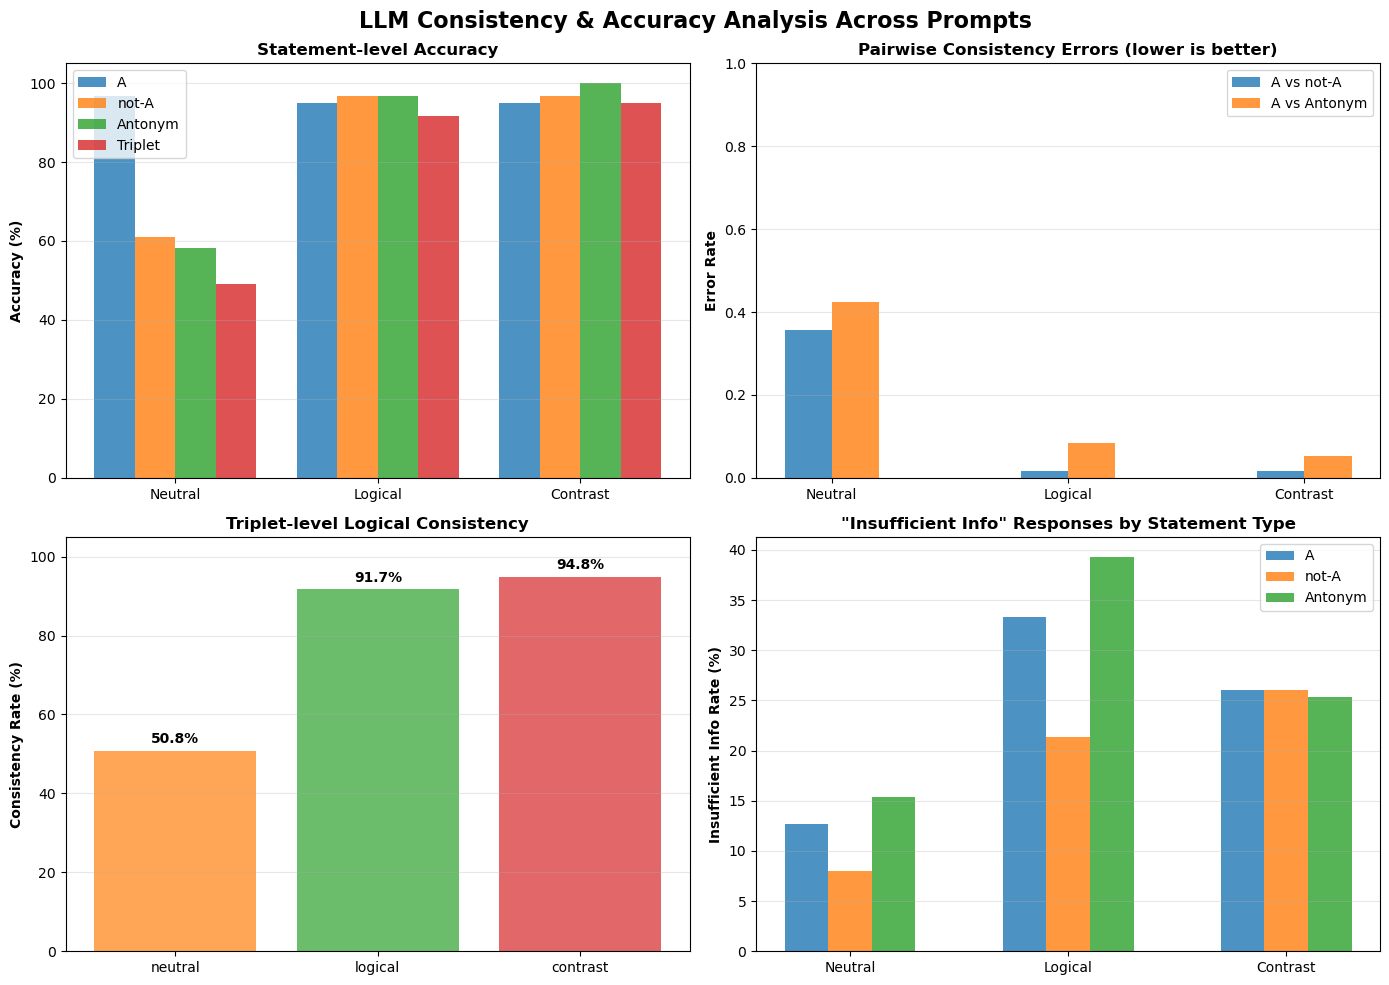

In [71]:
# ========================================
# 4. VISUALIZATIONS
# ========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LLM Consistency & Accuracy Analysis Across Prompts', fontsize=16, fontweight='bold')

# Extract raw numeric values for plotting
modes = accuracy_df['Mode'].values
acc_A_vals = [float(accuracy_df.iloc[i]['_acc_A_raw']) for i in range(len(accuracy_df))]
acc_notA_vals = [float(accuracy_df.iloc[i]['_acc_notA_raw']) for i in range(len(accuracy_df))]
acc_ant_vals = [float(accuracy_df.iloc[i]['_acc_ant_raw']) for i in range(len(accuracy_df))]
triplet_vals = [float(accuracy_df.iloc[i]['_triplet_raw']) for i in range(len(accuracy_df))]

# ---- Plot 1: Statement-level accuracy comparison ----
x = np.arange(len(modes))
width = 0.2
ax = axes[0, 0]
ax.bar(x - 1.5*width, acc_A_vals, width, label='A', alpha=0.8)
ax.bar(x - 0.5*width, acc_notA_vals, width, label='not-A', alpha=0.8)
ax.bar(x + 0.5*width, acc_ant_vals, width, label='Antonym', alpha=0.8)
ax.bar(x + 1.5*width, triplet_vals, width, label='Triplet', alpha=0.8, color='#d62728')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Statement-level Accuracy', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in modes])
ax.legend()
ax.set_ylim([0, 105])
ax.grid(axis='y', alpha=0.3)

# ---- Plot 2: Consistency error rates ----
contra_errors = consistency_df['contradiction_error_rate'].fillna(0).values
ant_errors = consistency_df['antonym_error_rate'].fillna(0).values
ax = axes[0, 1]
ax.bar(x - width/2, contra_errors, width, label='A vs not-A', alpha=0.8)
ax.bar(x + width/2, ant_errors, width, label='A vs Antonym', alpha=0.8)
ax.set_ylabel('Error Rate', fontweight='bold')
ax.set_title('Pairwise Consistency Errors (lower is better)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in modes])
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# ---- Plot 3: Triplet consistency ----
triplet_consistency = consistency_df['triplet_consistency_rate'].fillna(0).values * 100
ax = axes[1, 0]
bars = ax.bar(modes, triplet_consistency, color=['#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
ax.set_ylabel('Consistency Rate (%)', fontweight='bold')
ax.set_title('Triplet-level Logical Consistency', fontweight='bold')
ax.set_ylim([0, 105])
for i, (bar, val) in enumerate(zip(bars, triplet_consistency)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}%',
            ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# ---- Plot 4: Insufficient Info rates ----
pct_A = [float(abstention_df.iloc[i]['Pct_Insufficient_A'].rstrip('%')) for i in range(len(abstention_df))]
pct_notA = [float(abstention_df.iloc[i]['Pct_Insufficient_notA'].rstrip('%')) for i in range(len(abstention_df))]
pct_ant = [float(abstention_df.iloc[i]['Pct_Insufficient_antonym'].rstrip('%')) for i in range(len(abstention_df))]

ax = axes[1, 1]
ax.bar(x - width, pct_A, width, label='A', alpha=0.8)
ax.bar(x, pct_notA, width, label='not-A', alpha=0.8)
ax.bar(x + width, pct_ant, width, label='Antonym', alpha=0.8)
ax.set_ylabel('Insufficient Info Rate (%)', fontweight='bold')
ax.set_title('"Insufficient Info" Responses by Statement Type', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in modes])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('statistics_overview.png', dpi=300, bbox_inches='tight')
print("✓ Saved visualization: statistics_overview.png")
plt.show()


# Calibration Analysis
Measures the model’s **confidence behavior**: how confident it is when it is correct vs when it is wrong, and how well its stated confidence matches its actual accuracy (calibration).

Steps:
- Detects filtered or invalid responses → Responses blocked by the safety filter or parser are excluded from calibration calculations.
- Tracks abstentions → Responses labeled as *Insufficient info* are counted and reported as a separate, meaningful behavior (the model chooses not to answer), but excluded from calibration metrics.
- Checks correctness → Compares the model’s predicted label with the ground truth for A, not-A, and antonym.
- Reshapes the data → Converts A / not-A / antonym into a single “long format” table, with one row per judgment and its confidence.
- Computes core calibration metrics →
  - Average confidence on correct vs incorrect answers (calibration gap).
  - **Brier score**: mean squared error between predicted confidence and actual outcome (lower = better calibrated).
  - **Expected Calibration Error (ECE)**: weighted average gap between confidence and accuracy across confidence bins (lower = better calibrated).
- Binning analysis → Confidence scores are grouped into bins (e.g., 0–20, 21–40, 41–60, 61–80, 81–100) and, for each bin, the code compares:
  - Average confidence vs actual accuracy.
  - Whether the model is overconfident, underconfident, or well-calibrated in that confidence range.
- Reliability diagram → Plots the ideal calibration line vs the model’s empirical curve (accuracy vs confidence), allowing visual inspection of overconfidence and underconfidence across confidence levels.



In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import brier_score_loss

In [65]:
def compute_calibration(result_df, mode_name=""):
    # ⚠️ SUBSET TO FIRST 60 ROWS FOR THIS ANALYSIS ONLY
    df = results_df.head(60).copy()

    # Convert ground truth to strings for comparison
    df["ground_truth_A_str"] = df["ground_truth_A"].apply(lambda x: "True" if x == True else "False")
    df["ground_truth_notA_str"] = df["ground_truth_notA"].apply(lambda x: "True" if x == True else "False")
    df["ground_truth_antonym_str"] = df["ground_truth_antonym"].apply(lambda x: "True" if x == True else "False")

    long_data = []

    #track abstensions (insufficient info)
    abstention_count = 0
    total_responses = 0

    # Detect filtered responses & correctness for each statement type
    for col, gt_col in [("A", "ground_truth_A_str"),
                        ("notA", "ground_truth_notA_str"),
                        ("antonym", "ground_truth_antonym_str")]:

        # 1. detect "Insufficient Info" specifically
        is_abstention = df[f"model_label_{col}"].str.contains("Insufficient info", case=False, na=False)
        abstention_count += is_abstention.sum()
        total_responses += len(df)

         # 2. detect Filtered/Error (excluding insufficient info for now)
        is_filtered_error = df[f"model_label_{col}"].str.contains("Filtered|ParsingError|ERROR", case=False, na=False)
        # Combine them for the final "invalid" mask
        # is_invalid = filtered OR abstention
        df[f"is_filtered_{col}"] = is_filtered_error | is_abstention

        # for non-filtered -> correct = model label matches ground truth
        df[f"correct_{col}"] = np.where(
            ~df[f"is_filtered_{col}"],
            df[f"model_label_{col}"] == df[gt_col],
            np.nan)


    # Convert the 3-column structure into "long" format for analysis
    long_data = []
    for col in ["A", "notA", "antonym"]:
        temp = pd.DataFrame({
            "correct": df[f"correct_{col}"],
            "confidence": df[f"model_conf_{col}"],
            "statement_type": col,
            "antonym_type": df["antonym_type"],
            "is_filtered": df[f"is_filtered_{col}"]
        })
        long_data.append(temp)

    long_df = pd.concat(long_data, ignore_index=True)

    # Keep only unfiltered responses
    valid_df = long_df[~long_df["is_filtered"]].copy()

    if len(valid_df) == 0:
        print(f"\n⚠️ No valid responses for calibration analysis in {mode_name}")
        return None

    #add brier score
    probs = valid_df["confidence"].values / 100
    y_true = valid_df["correct"].astype(int)
    brier = brier_score_loss(y_true, probs)

    # Compute calibration metrics
    avg_conf_correct = valid_df[valid_df["correct"] == True]["confidence"].mean()
    avg_conf_wrong = valid_df[valid_df["correct"] == False]["confidence"].mean()
    calibration_gap = avg_conf_correct - avg_conf_wrong  # positive → better calibrated

    # Also compute accuracy overall
    overall_accuracy = valid_df["correct"].mean()
    avg_confidence = valid_df["confidence"].mean()
    expected_accuracy_from_conf = avg_confidence / 100

    # Confidence binning (0–20%, 21–40%, etc.)
    valid_df["conf_bin"] = pd.cut(
        valid_df["confidence"],
        bins=[0, 20, 40, 60, 80, 100],
        labels=["0-20", "21-40", "41-60", "61-80", "81-100"],
        include_lowest=True)

    bin_stats = []

    #compute ECE
    ece = 0.0
    n_total = len(valid_df)

    for bin_name in ["0-20", "21-40", "41-60", "61-80", "81-100"]:
        bin_data = valid_df[valid_df["conf_bin"] == bin_name]
        if len(bin_data) > 0:
            accuracy = bin_data["correct"].mean()
            avg_conf = bin_data["confidence"].mean()
            count = len(bin_data)

            # Expected accuracy if perfectly calibrated → confidence/100
            expected_accuracy = avg_conf / 100
            calibration_diff = accuracy - expected_accuracy

            bin_weight = count / n_total
            ece += bin_weight * abs(accuracy - expected_accuracy)

            bin_stats.append({
                "bin": bin_name,
                "count": count,
                "avg_confidence": avg_conf,
                "accuracy": accuracy,
                "expected_accuracy": expected_accuracy,
                "calibration_diff": calibration_diff})

    # Print summary
    print(f"\n{'='*60}")
    print(f"CALIBRATION ANALYSIS: {mode_name.upper()}")
    print(f"{'='*60}")
    print(f"Valid responses for calibration: {len(valid_df)}")
    #new print added
    print(f"Absentions (insufficient info): {abstention_count}")
    print(f"Overall accuracy: {overall_accuracy:.3f}")
    print(f"Average confidence: {avg_confidence:.1f}")
    print(f"Expected accuracy if perfectly calibrated: {expected_accuracy_from_conf:.3f}")

    #new print added
    print(f"brier score: {brier:.4f} (lower is better)")
    print(f"ECE: {ece:.4f} (lower is better)")

    print(f"\nAverage confidence by correctness:")
    print(f"  Correct answers: {avg_conf_correct:.1f} ({valid_df[valid_df['correct'] == True]['confidence'].count()} items)")
    print(f"  Wrong answers:   {avg_conf_wrong:.1f} ({valid_df[valid_df['correct'] == False]['confidence'].count()} items)")
    print(f"  Calibration gap: {calibration_gap:.1f} (positive = well-calibrated)")

    # Interpretation of gap
    if calibration_gap > 10:
        print(f"  ✓ STRONGLY well-calibrated (model more confident when correct)")
    elif calibration_gap > 5:
        print(f"  ○ Moderately well-calibrated")
    elif calibration_gap > -5:
        print(f"  ~ Neutral calibration")
    elif calibration_gap > -10:
        print(f"  ⚠️ Slightly poorly calibrated")
    else:
        print(f"  ✗ POORLY calibrated (model overconfident when wrong)")

    print(f"\nConfidence bin analysis:")
    for stat in bin_stats:
        # Interpret the calibration difference
        if stat["calibration_diff"] < -0.10:
            cal_status = "STRONGLY OVERCONFIDENT"
        elif stat["calibration_diff"] < -0.05:
            cal_status = "overconfident"
        elif stat["calibration_diff"] > 0.10:
            cal_status = "STRONGLY UNDERCONFIDENT"
        elif stat["calibration_diff"] > 0.05:
            cal_status = "underconfident"
        else:
            cal_status = "well-calibrated"

        print(f"  {stat['bin']}%: {stat['count']:3d} responses")
        print(f"      Avg confidence: {stat['avg_confidence']:5.1f} | "
              f"Actual accuracy: {stat['accuracy']:.3f} | "
              f"Expected: {stat['expected_accuracy']:.3f}")
        print(f"      Calibration diff: {stat['calibration_diff']:+.3f} → {cal_status}")

    # add plot
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], "k:", label="Perfect")

    # Extract data for plot
    x_plot = [b['avg_confidence']/100 for b in bin_stats]
    y_plot = [b['accuracy'] for b in bin_stats]

    plt.plot(x_plot, y_plot, "s-", label=f"{mode_name} (ECE={ece:.2f})")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Calibration: {mode_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "mode": mode_name,
        "valid_responses": len(valid_df),
        "overall_accuracy": overall_accuracy,
        "avg_confidence": avg_confidence,
        "expected_accuracy": expected_accuracy_from_conf,
        "avg_conf_correct": avg_conf_correct,
        "avg_conf_wrong": avg_conf_wrong,
        "calibration_gap": calibration_gap,
        "bin_stats": bin_stats}


CALIBRATION ANALYSIS: NEUTRAL
Valid responses for calibration: 176
Absentions (insufficient info): 4
Overall accuracy: 0.972
Average confidence: 96.5
Expected accuracy if perfectly calibrated: 0.965
brier score: 0.0249 (lower is better)
ECE: 0.0065 (lower is better)

Average confidence by correctness:
  Correct answers: 96.7 (171 items)
  Wrong answers:   90.0 (5 items)
  Calibration gap: 6.7 (positive = well-calibrated)
  ○ Moderately well-calibrated

Confidence bin analysis:
  81-100%: 176 responses
      Avg confidence:  96.5 | Actual accuracy: 0.972 | Expected: 0.965
      Calibration diff: +0.007 → well-calibrated


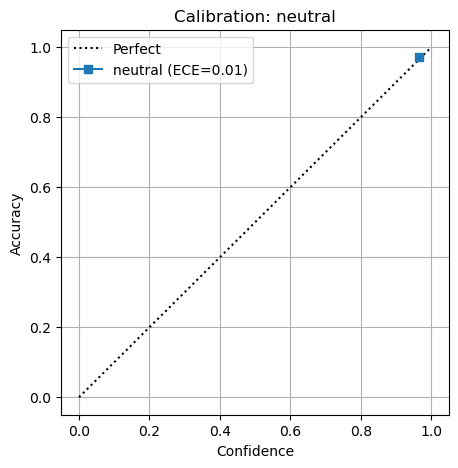


CALIBRATION ANALYSIS: LOGICAL
Valid responses for calibration: 176
Absentions (insufficient info): 4
Overall accuracy: 0.972
Average confidence: 96.5
Expected accuracy if perfectly calibrated: 0.965
brier score: 0.0249 (lower is better)
ECE: 0.0065 (lower is better)

Average confidence by correctness:
  Correct answers: 96.7 (171 items)
  Wrong answers:   90.0 (5 items)
  Calibration gap: 6.7 (positive = well-calibrated)
  ○ Moderately well-calibrated

Confidence bin analysis:
  81-100%: 176 responses
      Avg confidence:  96.5 | Actual accuracy: 0.972 | Expected: 0.965
      Calibration diff: +0.007 → well-calibrated


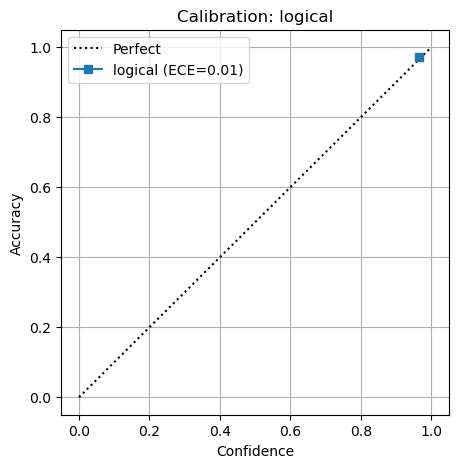


CALIBRATION ANALYSIS: CONTRAST
Valid responses for calibration: 176
Absentions (insufficient info): 4
Overall accuracy: 0.972
Average confidence: 96.5
Expected accuracy if perfectly calibrated: 0.965
brier score: 0.0249 (lower is better)
ECE: 0.0065 (lower is better)

Average confidence by correctness:
  Correct answers: 96.7 (171 items)
  Wrong answers:   90.0 (5 items)
  Calibration gap: 6.7 (positive = well-calibrated)
  ○ Moderately well-calibrated

Confidence bin analysis:
  81-100%: 176 responses
      Avg confidence:  96.5 | Actual accuracy: 0.972 | Expected: 0.965
      Calibration diff: +0.007 → well-calibrated


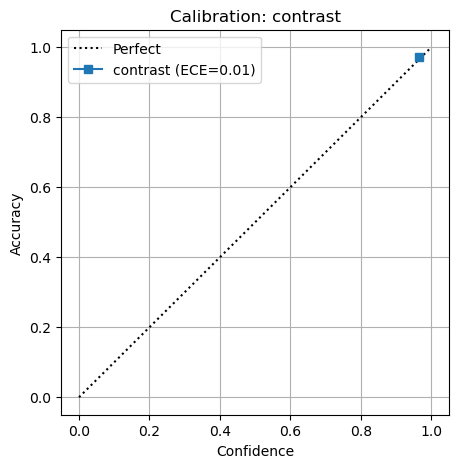

In [66]:
# Run calibration for all modes
calib_neutral = compute_calibration(results_neutral, "neutral")
calib_logical = compute_calibration(results_logical, "logical")
calib_contrast = compute_calibration(results_contrast, "contrast")

In [67]:
# ========================================
# 5. STATISTICAL SIGNIFICANCE TESTING (McNemar & Calibration Comparison)
# ========================================

from scipy.stats import chi2

def mcnemar_test(table):
    """
    Manual implementation of McNemar test.
    table: 2x2 contingency matrix
           [[n00, n01],   where n_ij = count for (condition1, condition2)
            [n10, n11]]
    Returns: chi2_stat, p_value
    """
    n01 = table.iloc[0, 1]  # correct in 1, wrong in 2
    n10 = table.iloc[1, 0]  # wrong in 1, correct in 2

    if n01 + n10 == 0:
        return np.nan, np.nan

    # McNemar statistic
    chi2_stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    p_value = 1 - chi2.cdf(chi2_stat, df=1)

    return chi2_stat, p_value

print("="*60)
print("STATISTICAL SIGNIFICANCE ANALYSIS")
print("="*60)

# ========== McNemar Test for Accuracy ==========

def run_mcnemar_test(results_df1, results_df2, label_col, comparison_name):
    """
    Run McNemar test on binary predictions from two conditions.
    Returns: statistic, p-value
    """
    # Extract valid responses (exclude filtered/insufficient)
    valid_mask1 = ~is_invalid_response(results_df1[label_col])
    valid_mask2 = ~is_invalid_response(results_df2[label_col])
    valid_both = valid_mask1 & valid_mask2

    if valid_both.sum() == 0:
        return None, None

    results_df1_valid = results_df1[valid_both].reset_index(drop=True)
    results_df2_valid = results_df2[valid_both].reset_index(drop=True)

    # Get ground truth
    truth_col = label_col.replace('model_label_', 'ground_truth_')
    truth = results_df1_valid[truth_col].astype(str)

    # Calculate correctness for each condition
    correct1 = results_df1_valid[label_col] == truth
    correct2 = results_df2_valid[label_col] == truth

    # Build contingency table: rows=correct in cond1, cols=correct in cond2
    table = pd.crosstab(correct1, correct2)

    # Run McNemar test
    if len(table) == 2 and table.shape == (2, 2):
        stat, pval = mcnemar_test(table)
    else:
        stat, pval = np.nan, np.nan

    return stat, pval

# McNemar tests for all pairwise comparisons
print("\n" + "-"*60)
print("McNemar Tests: Accuracy Differences Between Prompts")
print("-"*60)

mcnemar_results = []

comparisons = [
    (results_neutral, results_logical, "Neutral vs Logical"),
    (results_neutral, results_contrast, "Neutral vs Contrast"),
    (results_logical, results_contrast, "Logical vs Contrast")
]

for results1, results2, comparison_name in comparisons:
    print(f"\n{comparison_name}:")

    for label_col in ['model_label_A', 'model_label_notA', 'model_label_antonym']:
        stmt_type = label_col.replace('model_label_', '').upper()

        stat, pval = run_mcnemar_test(results1, results2, label_col, comparison_name)

        if stat is not None and not pd.isna(stat):
            significance = "✓ Significant (p < 0.05)" if pval < 0.05 else "✗ Not significant (p ≥ 0.05)"
            print(f"  {stmt_type}: χ² = {stat:.3f}, p-value = {pval:.4f} {significance}")

            mcnemar_results.append({
                'Comparison': comparison_name,
                'Statement_Type': stmt_type,
                'Chi_Square': f"{stat:.3f}",
                'P_Value': f"{pval:.4f}",
                'Significant': 'Yes' if pval < 0.05 else 'No'
            })
        else:
            print(f"  {stmt_type}: Insufficient valid pairs or NaN")

# Save McNemar results
mcnemar_df = pd.DataFrame(mcnemar_results)
mcnemar_df.to_csv('05_mcnemar_accuracy_tests.csv', index=False)
print(f"\n✓ Saved: 05_mcnemar_accuracy_tests.csv")

# ========== McNemar Test for Consistency ==========
print("\n" + "-"*60)
print("McNemar Tests: Consistency Differences Between Prompts")
print("-"*60)

def run_mcnemar_consistency(results_df1, results_df2, comparison_name):
    """
    McNemar test on consistency: contradiction errors between prompts
    """
    df1 = results_df1.copy()
    df2 = results_df2.copy()

    # Create consistency masks using utility function
    bad_A1 = is_invalid_response(df1['model_label_A'])
    bad_notA1 = is_invalid_response(df1['model_label_notA'])
    bad_A2 = is_invalid_response(df2['model_label_A'])
    bad_notA2 = is_invalid_response(df2['model_label_notA'])

    # Contradiction error: True if A and not-A have same label (error)
    contra_error1 = np.where(
        ~(bad_A1 | bad_notA1),
        df1["model_label_A"] == df1["model_label_notA"],
        np.nan
    )
    contra_error2 = np.where(
        ~(bad_A2 | bad_notA2),
        df2["model_label_A"] == df2["model_label_notA"],
        np.nan
    )

    # Get valid pairs for both
    valid_both = ~(pd.isna(contra_error1) | pd.isna(contra_error2))
    if valid_both.sum() == 0:
        return None, None

    contra1_valid = contra_error1[valid_both].astype(bool)
    contra2_valid = contra_error2[valid_both].astype(bool)

    # McNemar table
    table = pd.crosstab(contra1_valid, contra2_valid)
    if len(table) == 2 and table.shape == (2, 2):
        stat, pval = mcnemar_test(table)
        return stat, pval
    else:
        return np.nan, np.nan

consistency_mcnemar = []
for results1, results2, comparison_name in comparisons:
    stat, pval = run_mcnemar_consistency(results1, results2, comparison_name)
    if not pd.isna(stat):
        significance = "✓ Significant" if pval < 0.05 else "✗ Not significant"
        print(f"{comparison_name}: χ² = {stat:.3f}, p-value = {pval:.4f} {significance}")

        consistency_mcnemar.append({
            'Comparison': comparison_name,
            'Metric': 'Contradiction_Consistency',
            'Chi_Square': f"{stat:.3f}",
            'P_Value': f"{pval:.4f}",
            'Significant': 'Yes' if pval < 0.05 else 'No'
        })

consistency_mcnemar_df = pd.DataFrame(consistency_mcnemar)
consistency_mcnemar_df.to_csv('05b_mcnemar_consistency_tests.csv', index=False)
print(f"\n✓ Saved: 05b_mcnemar_consistency_tests.csv")

# ========== Compare Calibration Metrics Across Modes (from CELLA 5.5) ==========
print("\n" + "-"*60)
print("Calibration Metric Comparisons")
print("-"*60)

# Run calibration for all modes (if not already done)
if 'calibration_results' not in locals():
    calibration_results = []

    for results_df, mode_name in [
        (results_neutral, "neutral"),
        (results_logical, "logical"),
        (results_contrast, "contrast")
    ]:
        cal_result = compute_calibration(results_df, mode_name)
        if cal_result is not None:
            calibration_results.append(cal_result)

# Extract and compare calibration metrics
calibration_comparison = []

if len(calibration_results) >= 1:
    for cal in calibration_results:
        # Compute ECE from bin_stats
        ece = 0.0
        total_count = sum([stat['count'] for stat in cal['bin_stats']])

        for stat in cal['bin_stats']:
            bin_weight = stat['count'] / total_count if total_count > 0 else 0
            ece += bin_weight * abs(stat['calibration_diff'])

        # Compute Brier Score
        probs = np.array([stat['expected_accuracy'] for stat in cal['bin_stats']])
        accuracies = np.array([stat['accuracy'] for stat in cal['bin_stats']])
        brier = np.mean((probs - accuracies) ** 2)

        calibration_comparison.append({
            'Mode': cal['mode'],
            'ECE': f"{ece:.4f}",
            'Brier_Score': f"{brier:.4f}",
            'Calibration_Gap': f"{cal['calibration_gap']:.2f}",
            'Overall_Accuracy': f"{cal['overall_accuracy']:.3f}",
            'Avg_Confidence': f"{cal['avg_confidence']:.1f}%"
        })

    calibration_comp_df = pd.DataFrame(calibration_comparison)
    calibration_comp_df.to_csv('05c_calibration_metrics_comparison.csv', index=False)
    print(f"\n{calibration_comp_df.to_string(index=False)}")
    print(f"\n✓ Saved: 05c_calibration_metrics_comparison.csv")

    # ---- Interpretation ----
    print(f"\n" + "-"*60)
    print("Calibration Interpretation:")
    print("-"*60)

    # ECE comparison
    ece_values = [float(cal['ECE']) for cal in calibration_comparison]
    best_ece_idx = ece_values.index(min(ece_values))
    worst_ece_idx = ece_values.index(max(ece_values))

    print(f"Best calibrated (lowest ECE): {calibration_comparison[best_ece_idx]['Mode'].upper()} ({min(ece_values):.4f})")
    print(f"Worst calibrated (highest ECE): {calibration_comparison[worst_ece_idx]['Mode'].upper()} ({max(ece_values):.4f})")

    # Calibration gap interpretation
    print(f"\nCalibration gaps (positive = well-calibrated):")
    for cal_comp in calibration_comparison:
        gap = float(cal_comp['Calibration_Gap'])
        if gap > 10:
            status = "✓ STRONGLY well-calibrated"
        elif gap > 5:
            status = "○ Moderately well-calibrated"
        elif gap > -5:
            status = "~ Neutral"
        elif gap > -10:
            status = "⚠️ Slightly poorly calibrated"
        else:
            status = "✗ POORLY calibrated (overconfident)"

        print(f"  {cal_comp['Mode'].upper()}: {gap} → {status}")

print("\n" + "="*60)
print("✓ Statistical significance analysis complete")
print("="*60)


STATISTICAL SIGNIFICANCE ANALYSIS

------------------------------------------------------------
McNemar Tests: Accuracy Differences Between Prompts
------------------------------------------------------------

Neutral vs Logical:
  A: χ² = 0.000, p-value = 1.0000 ✗ Not significant (p ≥ 0.05)
  NOTA: χ² = 19.048, p-value = 0.0000 ✓ Significant (p < 0.05)
  ANTONYM: χ² = 21.043, p-value = 0.0000 ✓ Significant (p < 0.05)

Neutral vs Contrast:
  A: χ² = 0.000, p-value = 1.0000 ✗ Not significant (p ≥ 0.05)
  NOTA: χ² = 19.048, p-value = 0.0000 ✓ Significant (p < 0.05)
  ANTONYM: χ² = 22.042, p-value = 0.0000 ✓ Significant (p < 0.05)

Logical vs Contrast:
  A: Insufficient valid pairs or NaN
  NOTA: Insufficient valid pairs or NaN
  ANTONYM: χ² = 0.000, p-value = 1.0000 ✗ Not significant (p ≥ 0.05)

✓ Saved: 05_mcnemar_accuracy_tests.csv

------------------------------------------------------------
McNemar Tests: Consistency Differences Between Prompts
---------------------------------------